![Cabec%CC%A7alho_notebook.png](cabecalho_notebook.png)

# Classificação de Atividade Humana com PCA

Vamos trabalhar com a base da demonstração feita em aula, mas vamos explorar um pouco melhor como é o desempenho da árvore variando o número de componentes principais.

In [ ]:
# Importa a biblioteca pandas para manipulação de dados
import pandas as pd

# Importa matplotlib para visualização de gráficos
import matplotlib.pyplot as plt

# Importa seaborn para gráficos estatísticos
import seaborn as sns

# Importa o classificador de árvore de decisão do scikit-learn
from sklearn.tree import DecisionTreeClassifier

# Importa o PCA para análise de componentes principais
from sklearn.decomposition import PCA

# Importa a função para calcular acurácia
from sklearn.metrics import accuracy_score

# Importa a função para plotar matriz de confusão
from sklearn.metrics import ConfusionMatrixDisplay

import numpy as np

In [142]:
# Definição dos caminhos para os arquivos de dados
filename_features = "./input/UCI HAR Dataset/features.txt"  # Arquivo com os nomes das variáveis (features)
filename_labels = "./input/UCI HAR Dataset/activity_labels.txt"  # Arquivo com os rótulos das atividades

filename_subtrain = "./input/UCI HAR Dataset/train/subject_train.txt"  # Arquivo com os IDs dos sujeitos no conjunto de treino
filename_xtrain = "./input/UCI HAR Dataset/train/X_train.txt"  # Arquivo com os dados de treino (features)
filename_ytrain = "./input/UCI HAR Dataset/train/y_train.txt"  # Arquivo com os rótulos das atividades no conjunto de treino

filename_subtest = "./input/UCI HAR Dataset/test/subject_test.txt"  # Arquivo com os IDs dos sujeitos no conjunto de teste
filename_xtest = "./input/UCI HAR Dataset/test/X_test.txt"  # Arquivo com os dados de teste (features)
filename_ytest = "./input/UCI HAR Dataset/test/y_test.txt"  # Arquivo com os rótulos das atividades no conjunto de teste

# Carregando os nomes das variáveis (features) a partir do arquivo
features = pd.read_csv(
    filename_features, header=None, names=["nome_var"], sep="#"
)  # Lê o arquivo de features
features = features.squeeze()  # Converte para uma série unidimensional

# Carregando os rótulos das atividades
labels = pd.read_csv(
    filename_labels, delim_whitespace=True, header=None, names=["cod_label", "label"]
)  # Lê o arquivo de rótulos

# Carregando os IDs dos sujeitos no conjunto de treino
subject_train = pd.read_csv(
    filename_subtrain, header=None, names=["subject_id"]
)  # Lê os IDs dos sujeitos no treino
subject_train = subject_train.squeeze()  # Converte para uma série unidimensional

# Carregando os dados de treino (features e rótulos)
X_train = pd.read_csv(
    filename_xtrain, delim_whitespace=True, header=None, names=features.tolist()
)  # Lê os dados de treino
y_train = pd.read_csv(
    filename_ytrain, header=None, names=["cod_label"]
)  # Lê os rótulos do treino

# Carregando os IDs dos sujeitos no conjunto de teste
subject_test = pd.read_csv(
    filename_subtest, header=None, names=["subject_id"]
)  # Lê os IDs dos sujeitos no teste
subject_test = subject_test.squeeze()  # Converte para uma série unidimensional

# Carregando os dados de teste (features e rótulos)
X_test = pd.read_csv(
    filename_xtest, delim_whitespace=True, header=None, names=features.tolist()
)  # Lê os dados de teste
y_test = pd.read_csv(
    filename_ytest, header=None, names=["cod_label"]
)  # Lê os rótulos do teste

C:\Users\hfasa\AppData\Local\Temp\ipykernel_12928\1629834542.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  labels = pd.read_csv(
C:\Users\hfasa\AppData\Local\Temp\ipykernel_12928\1629834542.py:31: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv(
C:\Users\hfasa\AppData\Local\Temp\ipykernel_12928\1629834542.py:45: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test = pd.read_csv(


## PCA com variáveis padronizadas

Reflexão sobre a escala das variáveis:

**Variáveis em métricas muito diferentes** podem interferir na análise de componentes principais. Lembra que variância é informação pra nós? Pois bem, tipicamente se há uma variável monetária como salário, vai ter uma ordem de variabilidade bem maior que número de filhos, tempo de emprego ou qualquer variável dummy. Assim, as variáveis de maior variância tendem a "dominar" a análise. Nesses casos é comum usar a padronização das variáveis.

Faça duas análises de componentes principais para a base do HAR - com e sem padronização e compare:

- A variância explicada por componente
- A variância explicada acumulada por componente
- A variância percentual por componente
- A variância percentual acumulada por componente
- Quantas componentes você escolheria, em cada caso para explicar 90% da variância?

### Não Padronizadas

In [143]:
%%time  

# Cria uma instância do PCA sem limitar o número de componentes
pca = PCA()  

# Ajusta o PCA aos dados de treino sem padronização
princomp = pca.fit(X_train)  

# Transforma os dados de treino para o espaço dos componentes principais
comp1_train = pca.transform(X_train)  

# Transforma os dados de teste para o espaço dos componentes principais
comp1_test = pca.transform(X_test)  


CPU times: total: 1.14 s
Wall time: 158 ms


In [144]:
# Cria um DataFrame com a variância explicada por cada componente principal
(
    pd.DataFrame(princomp.explained_variance_)  # Variância explicada (autovalores)
    .reset_index()  # Reseta o índice para facilitar o merge
    .rename(columns={"index": "Componentes", 0: "Variância explicada"})  # Renomeia as colunas

    # Faz o merge com a proporção da variância explicada (%)
    .merge(
        pd.DataFrame(princomp.explained_variance_ratio_ * 100)  # Proporção da variância explicada em %
        .reset_index()
        .rename(columns={"index": "Componentes", 0: "Proporção Variância explicada"})
    )

    # Faz o merge com a proporção acumulada da variância explicada (%)
    .merge(
        pd.DataFrame(princomp.explained_variance_ratio_.cumsum() * 100)  # Proporção acumulada em %
        .reset_index()
        .rename(columns={"index": "Componentes", 0: "Proporção Variância acumulada"})
    )
)

,Componentes,Variância explicada,Proporção Variância explicada,Proporção Variância acumulada
0,0,34.823630,62.554440,62.554440
1,1,2.735046,4.913023,67.467463
2,2,2.294393,4.121467,71.588930
3,3,1.043775,1.874956,73.463886
4,4,0.943517,1.694860,75.158746
...,...,...,...,...
556,556,0.000000,0.000000,100.000000
557,557,0.000000,0.000000,100.000000
558,558,0.000000,0.000000,100.000000
559,559,0.000000,0.000000,100.000000


In [145]:
# Imprime a soma da variância explicada por todos os componentes principais
print(
    "Soma da variância explicada: ", round(sum(princomp.explained_variance_)), 3
)

# Imprime a soma da variância percentual explicada (deve ser próximo de 1, ou 100%)
print(
    "Soma da variância percentual: ", round(sum(princomp.explained_variance_ratio_), 3)
)

# Imprime o número total de componentes principais calculados
print(
    "Número de componentes: ", len(princomp.explained_variance_ratio_)
)

Soma da variância explicada:  56 3
Soma da variância percentual:  1.0
Número de componentes:  561


In [146]:
# Função para plotar o scree plot e determinar o número ideal de componentes principais
def screeplot(princomp, ncomp=0, varexplicada=0, criterio=1):

    # Define o critério para o número de componentes principais a ser destacado
    if ncomp > 0:
        ncomp_crit = ncomp  # Usa o número de componentes informado pelo usuário
    elif varexplicada > 0:
        # Calcula o número de componentes necessários para atingir a variância explicada desejada
        ncomp_crit = (
            princomp.explained_variance_ratio_.cumsum() < varexplicada
        ).sum() + 1
    # Critério 1: autovalor padronizado > 1
    elif criterio == 1:
        ncomp_crit = (
            princomp.explained_variance_ratio_ > 1 / princomp.n_components_
        ).sum()
    else:
        ncomp_crit = None  # Não define nenhum critério

    # Cria uma grade de subplots para os gráficos
    fig, ax = plt.subplots(2, 2, sharex=True, figsize=(14, 8))
    plt.subplots_adjust(hspace=0, wspace=0.15)

    # Eixo X: número dos componentes principais
    num_componentes = np.arange(princomp.n_components_) + 1

    # Gráfico da variância explicada por componente
    ax[0, 0].plot(
        num_componentes,
        princomp.explained_variance_,
        "o-",
        linewidth=2,
        color="blue",
        markersize=2,
        alpha=0.2,
    )
    ax[0, 0].set_title("Scree Plot - Variância total")
    ax[0, 0].set_xlabel("Número de componentes")
    ax[0, 0].set_ylabel("Variancia explicada (Autovalores)")

    # Gráfico da variância explicada acumulada
    ax[1, 0].plot(
        num_componentes,
        princomp.explained_variance_.cumsum(),
        "o-",
        linewidth=2,
        color="blue",
        markersize=2,
        alpha=0.2,
    )
    ax[1, 0].set_xlabel("Número de componentes")
    ax[1, 0].set_ylabel("Variancia explicada (Acumulada)")

    # Gráfico da variância percentual explicada por componente
    ax[0, 1].plot(
        num_componentes,
        princomp.explained_variance_ratio_,
        "o-",
        linewidth=2,
        color="blue",
        markersize=2,
        alpha=0.2,
    )
    ax[0, 1].set_title("Scree Plot - Variância percentual")
    ax[0, 1].set_xlabel("Número de componentes")
    ax[0, 1].set_ylabel("Variancia explicada (percentual)")

    # Gráfico da variância percentual acumulada
    ax[1, 1].plot(
        num_componentes,
        princomp.explained_variance_ratio_.cumsum(),
        "o-",
        linewidth=2,
        color="blue",
        markersize=2,
        alpha=0.2,
    )
    ax[1, 1].set_xlabel("Número de componentes")
    ax[1, 1].set_ylabel("Variancia explicada (% Acumulado)")

    if ncomp_crit != None:
        # Linhas verticais de referência para o número de componentes escolhido
        ax[0, 0].axvline(x=ncomp_crit, color="r", linestyle="-", linewidth=0.5)
        ax[1, 1].axvline(x=ncomp_crit, color="r", linestyle="-", linewidth=0.5)
        ax[1, 0].axvline(x=ncomp_crit, color="r", linestyle="-", linewidth=0.5)
        ax[0, 1].axvline(x=ncomp_crit, color="r", linestyle="-", linewidth=0.5)

        # Linhas horizontais de referência para os valores correspondentes ao componente escolhido
        variancia = princomp.explained_variance_[ncomp_crit - 1]
        variancia_acumulada = princomp.explained_variance_.cumsum()[ncomp_crit - 1]
        pct_variancia = princomp.explained_variance_ratio_[ncomp_crit - 1]
        pct_variancia_acumulada = princomp.explained_variance_ratio_.cumsum()[
            ncomp_crit - 1
        ]

        ax[0, 0].axhline(y=variancia, color="r", linestyle="-", linewidth=0.5)
        ax[1, 0].axhline(y=variancia_acumulada, color="r", linestyle="-", linewidth=0.5)
        ax[0, 1].axhline(y=pct_variancia, color="r", linestyle="-", linewidth=0.5)
        ax[1, 1].axhline(
            y=pct_variancia_acumulada, color="r", linestyle="-", linewidth=0.5
        )

    # Exibe informações sobre o número de componentes e variância explicada
    print(f"Número de componentes:............... {ncomp_crit}")
    print(f"Variância da ultima CP:.............. {variancia:.2f}")
    print(f"Variância total explicada:........... {variancia_acumulada:.2f}")
    print(f"Variância percentual da última CP:... {100*pct_variancia:.2f}%")
    print(f"Variância percentual total explicada: {100*pct_variancia_acumulada:.2f}%")
    plt.show()
    return ncomp_crit

Número de componentes:............... 34
Variância da ultima CP:.............. 0.13
Variância total explicada:........... 50.15
Variância percentual da última CP:... 0.24%
Variância percentual total explicada: 90.09%


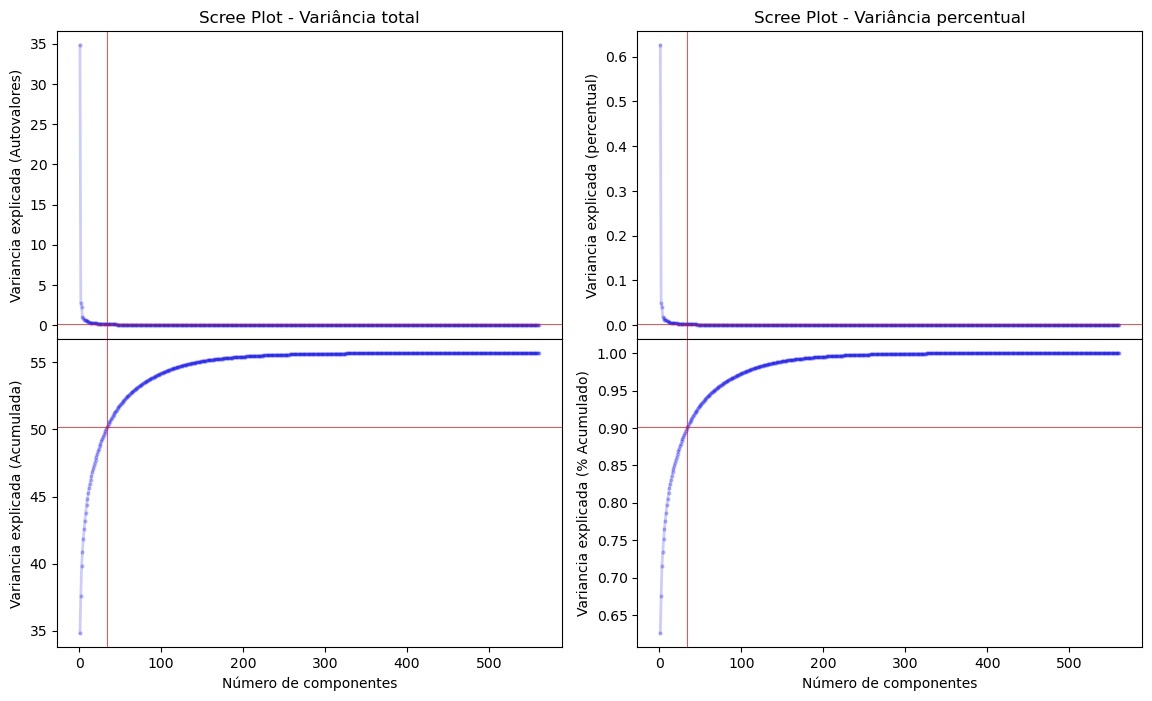

In [147]:
# Plota o screeplot para os componentes principais obtidos sem padronização
# O parâmetro varexplicada=0.90 indica que queremos saber quantos componentes são necessários para explicar 90% da variância
ncomp = screeplot(princomp, varexplicada=0.90)

### Padronizadas

In [ ]:
%%time  

# Função para padronizar uma série: subtrai a média e divide pelo desvio padrão, se o desvio for maior que zero
def padroniza(s):
    if s.std() > 0:
        s = (s - s.mean())/s.std()
    return s

# Aplica a padronização em cada coluna do conjunto de treino
X_train_pad = pd.DataFrame(X_train).apply(padroniza, axis=0)

# Aplica a padronização em cada coluna do conjunto de teste
X_test_pad = pd.DataFrame(X_test).apply(padroniza, axis=0)

# Exibe as primeiras linhas do dataframe padronizado
X_train_pad.head()

CPU times: total: 156 ms
Wall time: 165 ms


,1 tBodyAcc-mean()-X,2 tBodyAcc-mean()-Y,3 tBodyAcc-mean()-Z,4 tBodyAcc-std()-X,5 tBodyAcc-std()-Y,6 tBodyAcc-std()-Z,7 tBodyAcc-mad()-X,8 tBodyAcc-mad()-Y,9 tBodyAcc-mad()-Z,10 tBodyAcc-max()-X,...,552 fBodyBodyGyroJerkMag-meanFreq(),553 fBodyBodyGyroJerkMag-skewness(),554 fBodyBodyGyroJerkMag-kurtosis(),"555 angle(tBodyAccMean,gravity)","556 angle(tBodyAccJerkMean),gravityMean)","557 angle(tBodyGyroMean,gravityMean)","558 angle(tBodyGyroJerkMean,gravityMean)","559 angle(X,gravityMean)","560 angle(Y,gravityMean)","561 angle(Z,gravityMean)"
0,0.200628,-0.063678,-0.419600,-0.868755,-0.939377,-0.737479,-0.859758,-0.938955,-0.766385,-0.855978,...,-0.795305,0.025958,-0.276380,-0.360579,0.062935,-0.778374,-0.026079,-0.687172,0.407918,-0.007567
1,0.055944,0.031484,-0.253891,-0.875366,-0.923839,-0.849247,-0.868472,-0.921936,-0.848870,-0.871300,...,0.130605,-0.897296,-0.767938,0.133002,-0.021460,-1.218722,1.484369,-0.694091,0.409089,0.007875
2,0.073510,-0.043414,-0.076289,-0.868980,-0.907698,-0.893724,-0.863078,-0.898793,-0.896640,-0.863264,...,1.152257,-0.260860,-0.438286,-0.377815,0.391949,0.151197,1.704085,-0.702191,0.410260,0.026501
3,0.066691,-0.208407,-0.249695,-0.870566,-0.939959,-0.921743,-0.864445,-0.938060,-0.925216,-0.863264,...,1.112694,0.591005,0.463123,-0.135016,-0.033635,1.037781,-1.002951,-0.701636,0.414622,0.031712
4,0.030467,0.027585,-0.109840,-0.875128,-0.934815,-0.921281,-0.867325,-0.931726,-0.927965,-0.870201,...,-0.149567,-0.138505,-0.240296,0.340383,0.268468,1.125841,-1.276196,-0.700104,0.425434,0.045222


In [ ]:
prcomp2 = pca.fit(X_train_pad)  # Ajusta o PCA aos dados padronizados
comp2_train = pca.transform(
    X_train_pad
)  # Transforma os dados padronizados para o espaço PCA
comp2_test = pca.transform(X_test_pad)  # Transforma os dados de teste para o espaço PCA

In [150]:
# Cria um DataFrame com a variância explicada por cada componente principal
(
    pd.DataFrame(prcomp2.explained_variance_)  # Variância explicada (autovalores) de cada componente
    .reset_index()  # Reseta o índice para facilitar o merge
    .rename(columns={"index": "Componentes", 0: "Variância explicada"})  # Renomeia as colunas

    # Faz o merge com a proporção da variância explicada (%)
    .merge(
        pd.DataFrame(prcomp2.explained_variance_ratio_ * 100)  # Proporção da variância explicada em %
        .reset_index()
        .rename(columns={"index": "Componentes", 0: "Proporção Variância explicada"})
    )

    # Faz o merge com a proporção acumulada da variância explicada (%)
    .merge(
        pd.DataFrame(prcomp2.explained_variance_ratio_.cumsum() * 100)  # Proporção acumulada em %
        .reset_index()
        .rename(columns={"index": "Componentes", 0: "Proporção Variância acumulada"})
    )
)

,Componentes,Variância explicada,Proporção Variância explicada,Proporção Variância acumulada
0,0,284.882377,50.781172,50.781172
1,1,36.917616,6.580680,57.361853
2,2,15.744110,2.806437,60.168289
3,3,14.047175,2.503953,62.672242
4,4,10.593279,1.888285,64.560527
...,...,...,...,...
556,556,0.000000,0.000000,100.000000
557,557,0.000000,0.000000,100.000000
558,558,0.000000,0.000000,100.000000
559,559,0.000000,0.000000,100.000000


In [151]:
# Imprime a soma da variância explicada por todos os componentes principais
print(
    "Soma da variância explicada: ", round(sum(prcomp2.explained_variance_), 3)
)  # Soma dos autovalores (variância total explicada pelos componentes principais)

# Imprime a soma da variância percentual explicada (deve ser próximo de 1, ou 100%)
print(
    "Soma da variância percentual: ", round(sum(prcomp2.explained_variance_ratio_), 3)
)  # Soma das proporções de variância explicada (deve ser próximo de 1)

# Imprime o número total de componentes principais calculados
print(
    "Número de componentes: ", len(prcomp2.explained_variance_ratio_)
)  # Quantidade de componentes principais extraídos pelo PCA

Soma da variância explicada:  561.0
Soma da variância percentual:  1.0
Número de componentes:  561


Número de componentes:............... 63
Variância da ultima CP:.............. 0.99
Variância total explicada:........... 505.20
Variância percentual da última CP:... 0.18%
Variância percentual total explicada: 90.05%


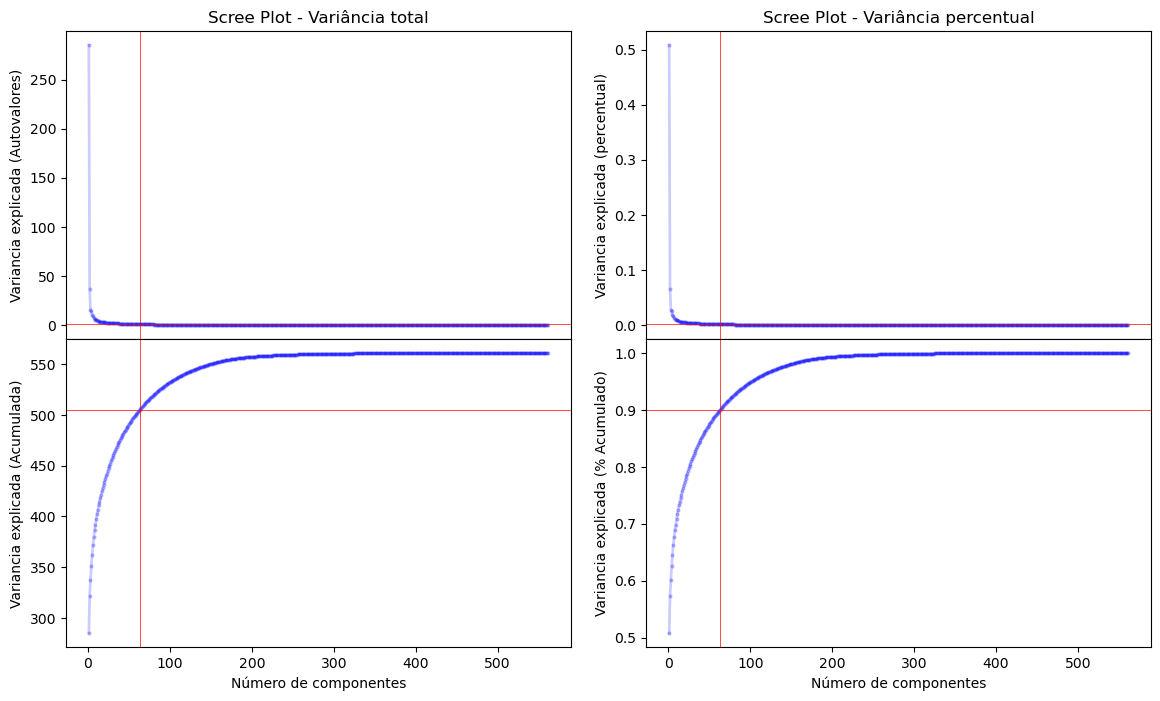

In [152]:
# Plota o screeplot para os componentes principais obtidos com padronização
# O parâmetro varexplicada=0.90 indica que queremos saber quantos componentes são necessários para explicar 90% da variância
ncomp = screeplot(prcomp2, varexplicada=0.90)

## Árvore com PCA

Faça duas uma árvore de decisão com 10 componentes principais - uma com base em dados padronizados e outra sem padronizar. Utilize o ```ccp_alpha=0.001```.

Compare a acurácia na base de treino e teste.

In [ ]:
%%time  

# Cria uma instância do PCA para reduzir para 10 componentes principais
pca = PCA(n_components=10)  

# Ajusta o PCA aos dados de treino sem padronização e transforma os dados de treino e teste
princomp = pca.fit(X_train)  # Ajusta o PCA aos dados de treino (sem padronização)
comp1_train = pca.transform(X_train)  # Transforma os dados de treino para o espaço dos 10 componentes principais
comp1_test = pca.transform(X_test)    # Transforma os dados de teste para o espaço dos 10 componentes principais

# Ajusta o PCA aos dados de treino padronizados e transforma os dados padronizados de treino e teste
prcomp2 = pca.fit(X_train_pad)        # Ajusta o PCA aos dados padronizados de treino
comp2_train = pca.transform(X_train_pad)  # Transforma os dados padronizados de treino para o espaço dos 10 componentes principais
comp2_test = pca.transform(X_test_pad)        # Transforma os dados de teste (não padronizados) para o espaço dos 10 componentes principais

CPU times: total: 1.33 s
Wall time: 187 ms


In [154]:
%%time

# Cria um classificador de árvore de decisão com parâmetro de complexidade ccp_alpha=0.001
clf_nd = DecisionTreeClassifier(ccp_alpha=0.001)

# Ajusta (treina) o classificador usando os dados de treino no espaço PCA sem padronização
clf_nd = clf_nd.fit(comp1_train, y_train)

CPU times: total: 891 ms
Wall time: 102 ms


In [155]:
%%time
# Cria um classificador de árvore de decisão com parâmetro de complexidade ccp_alpha=0.001
clf_def = DecisionTreeClassifier(ccp_alpha=0.001)

# Ajusta (treina) o classificador usando os dados de treino no espaço PCA padronizado
clf_def = clf_def.fit(comp2_train, y_train)

CPU times: total: 625 ms
Wall time: 83.6 ms


In [156]:
# Inicializa um dicionário para armazenar as acurácias dos modelos
acuracia_dos_modelos = {
    'acuracia_treino': {                # Acurácia na base de treino
        "sem_padronizacao": [],         # Lista para acurácias sem padronização
        "com_padronizacao": [],         # Lista para acurácias com padronização
    },
    'acuracia_teste': {                 # Acurácia na base de teste
        "sem_padronizacao": [],         # Lista para acurácias sem padronização
        "com_padronizacao": [],         # Lista para acurácias com padronização
    }
}

Acurácia do classificador (sem padronização): 0.89


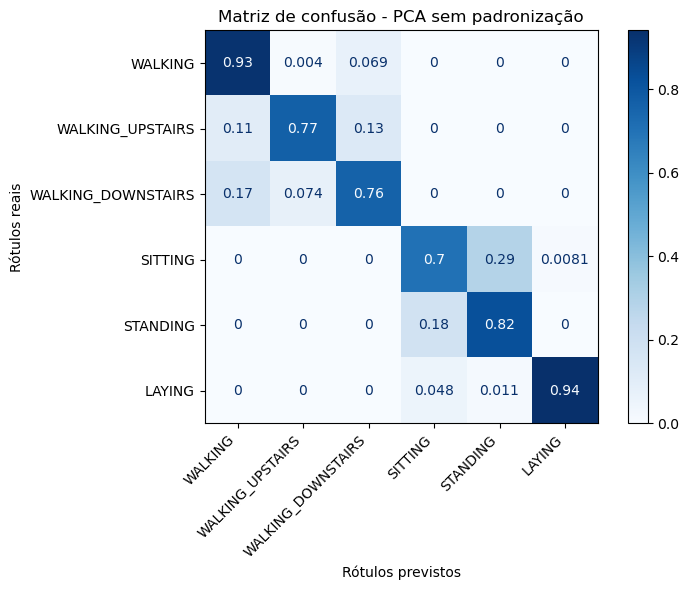

In [157]:
# Cria uma figura e um eixo para o gráfico
fig, ax = plt.subplots(figsize=(8, 6))

# Faz previsões nos dados de teste usando o classificador treinado sem padronização
y_pred = clf_nd.predict(comp1_test)

# Calcula a acurácia do classificador nos dados de teste e treino
acc_test = accuracy_score(y_test, y_pred)
acc_train = accuracy_score(y_train, clf_nd.predict(comp1_train))

# Armazena as acurácias no dicionário para posterior comparação
acuracia_dos_modelos['acuracia_teste']['sem_padronizacao'].append(acc_test)
acuracia_dos_modelos['acuracia_treino']['sem_padronizacao'].append(acc_train)

# Plota a matriz de confusão normalizada para os dados de teste
disp = ConfusionMatrixDisplay.from_estimator(
    clf_nd,                # classificador treinado
    comp1_test,            # dados de teste no espaço PCA (sem padronização)
    y_test,                # rótulos reais do teste
    display_labels=labels.label.tolist(),  # nomes das classes
    cmap=plt.cm.Blues,     # mapa de cores
    normalize="true",      # normaliza a matriz de confusão
    ax=ax                  # eixo onde será plotado
)

# Imprime a acurácia do classificador na base de treino
print(
    f"Acurácia do classificador (sem padronização): {acc_train:.2f}"
)

# Ajusta os títulos e rótulos do gráfico
plt.title("Matriz de confusão - PCA sem padronização")
plt.xlabel("Rótulos previstos")
plt.ylabel("Rótulos reais")
plt.xticks(rotation=45, ha="right")  # Rotaciona os rótulos do eixo X

# Ajusta o layout e exibe o gráfico
plt.tight_layout()
plt.show()

A acurácia do classificador (padronizado): 0.3593579978237214


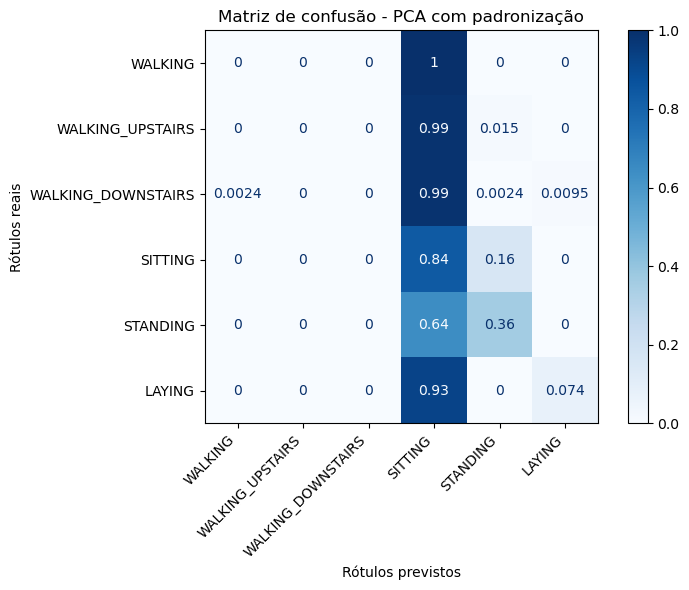

In [158]:
# Cria uma figura e um eixo para o gráfico
fig, ax = plt.subplots(figsize=(8, 6))

# Faz previsões nos dados de teste usando o classificador treinado sem padronização (isso está incorreto, veja nota abaixo)
y_pred = clf_nd.predict(comp2_test)

# Calcula a acurácia do classificador nos dados de teste e treino (também usando clf_nd, veja nota abaixo)
acc_test = accuracy_score(y_test, y_pred)
acc_train = accuracy_score(y_train, clf_nd.predict(comp2_train))

# Armazena as acurácias no dicionário para posterior comparação
acuracia_dos_modelos['acuracia_teste']['com_padronizacao'].append(acc_test)
acuracia_dos_modelos['acuracia_treino']['com_padronizacao'].append(acc_train)

# Plota a matriz de confusão normalizada para os dados de teste usando o classificador treinado com padronização
disp = ConfusionMatrixDisplay.from_estimator(
    clf_def,            # classificador treinado com dados padronizados
    comp2_test,         # dados de teste no espaço PCA padronizado
    y_test,             # rótulos reais do teste
    display_labels=labels.label.tolist(),  # nomes das classes
    cmap=plt.cm.Blues,  # mapa de cores
    normalize="true",   # normaliza a matriz de confusão
    ax=ax,              # eixo onde será plotado
)

# Imprime a acurácia do classificador na base de treino
print(
    "A acurácia do classificador (padronizado):", acc_train
)

# Ajusta os títulos e rótulos do gráfico
plt.title("Matriz de confusão - PCA com padronização")
plt.xlabel("Rótulos previstos")
plt.ylabel("Rótulos reais")
plt.xticks(rotation=45, ha="right")  # Rotaciona os rótulos do eixo X

# Ajusta o layout e exibe o gráfico
plt.tight_layout()
plt.show()

In [159]:
# Converte o dicionário de acurácia em um DataFrame e arredonda os valores para melhor visualização
(
    pd.DataFrame(acuracia_dos_modelos)  # Cria um DataFrame a partir do dicionário de acurácia
    .applymap(
        lambda x: [round(v, 3) for v in x] if isinstance(x, list) else round(x, 3)
    )  # Aplica o arredondamento a cada elemento: se for lista, arredonda cada item; se não, arredonda o valor
)

C:\Users\hfasa\AppData\Local\Temp\ipykernel_12928\298278003.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(


,acuracia_treino,acuracia_teste
sem_padronizacao,[0.893],[0.824]
com_padronizacao,[0.359],[0.181]
